In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

file_path = '/content/drive/MyDrive/Datasets/FaceMaskDetection'

for item in os.listdir(file_path):
    print(item)

annotations
images


In [ ]:
import os, struct
import numpy as np

MNIST_DIR = '/content/drive/MyDrive/Datasets/MNIST'

def read_idx(path):
    """Parse an IDX (ubyte) file into a numpy array."""
    with open(path, 'rb') as f:
        _, _, ndims = struct.unpack('>HBB', f.read(4))   # 2 zero bytes, dtype, ndims
        shape = tuple(struct.unpack('>I', f.read(4))[0] for _ in range(ndims))
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return data.reshape(shape)

def find_mnist_files(root):
    """
    Walk the folder and classify every real file by its IDX magic number,
    ignoring names. This sidesteps the dot/dash + nested-folder duplicates:
    images -> magic 2051, labels -> magic 2049.
    """
    found = {'train_images': None, 'train_labels': None,
             'test_images':  None, 'test_labels':  None}
    for dirpath, _, filenames in os.walk(root):
        for name in filenames:
            full = os.path.join(dirpath, name)
            try:
                with open(full, 'rb') as f:
                    magic = struct.unpack('>I', f.read(4))[0]
            except Exception:
                continue
            is_train = 'train' in name.lower()
            if magic == 2051:      # images
                key = 'train_images' if is_train else 'test_images'
            elif magic == 2049:    # labels
                key = 'train_labels' if is_train else 'test_labels'
            else:
                continue
            if found[key] is None:        # keep the first valid copy
                found[key] = full
    missing = [k for k, v in found.items() if v is None]
    if missing:
        raise FileNotFoundError(f"Could not find: {missing}")
    return found

files = find_mnist_files(MNIST_DIR)
for k, v in files.items():
    print(f"{k:13s} -> {v}")

X_train = read_idx(files['train_images']).astype(np.float32) / 255.0
y_train = read_idx(files['train_labels']).astype(np.int64)
X_test  = read_idx(files['test_images']).astype(np.float32) / 255.0
y_test  = read_idx(files['test_labels']).astype(np.int64)

print("Shapes:", X_train.shape, y_train.shape, X_test.shape, y_test.shape)

train_images  -> /content/drive/MyDrive/Datasets/MNIST/train-images.idx3-ubyte
train_labels  -> /content/drive/MyDrive/Datasets/MNIST/train-labels.idx1-ubyte
test_images   -> /content/drive/MyDrive/Datasets/MNIST/t10k-images.idx3-ubyte
test_labels   -> /content/drive/MyDrive/Datasets/MNIST/t10k-labels.idx1-ubyte
Shapes: (60000, 28, 28) (60000,) (10000, 28, 28) (10000,)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# add channel dim: (N, 28, 28) -> (N, 1, 28, 28)
train_ds = TensorDataset(torch.from_numpy(X_train).unsqueeze(1), torch.from_numpy(y_train))
test_ds  = TensorDataset(torch.from_numpy(X_test).unsqueeze(1),  torch.from_numpy(y_test))
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=256)

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,  8, kernel_size=3, padding=1)   # 28x28 -> 28x28
        self.conv2 = nn.Conv2d(8, 16, kernel_size=3, padding=1)   # 14x14 -> 14x14
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc    = nn.Linear(16 * 7 * 7, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # Conv -> ReLU -> MaxPool  (28 -> 14)
        x = self.pool(F.relu(self.conv2(x)))   # Conv -> ReLU -> MaxPool  (14 -> 7)
        x = x.flatten(1)
        return self.fc(x)

model = SmallCNN().to(device)
print(model)

Device: cpu
SmallCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=784, out_features=10, bias=True)
)


In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
EPOCHS = 2

for epoch in range(EPOCHS):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)
    print(f"Epoch {epoch+1}: train loss = {running/len(train_ds):.4f}")

# quick test accuracy
model.eval()
correct = 0
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        correct += (model(xb).argmax(1) == yb).sum().item()
print(f"Test accuracy: {100*correct/len(test_ds):.2f}%")

Epoch 1: train loss = 0.4784
Epoch 2: train loss = 0.1233
Test accuracy: 97.45%


Input label: 7
conv1: (1, 8, 28, 28) | relu: (1, 8, 28, 28) | pool: (1, 8, 14, 14)


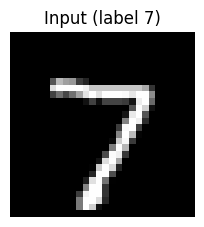

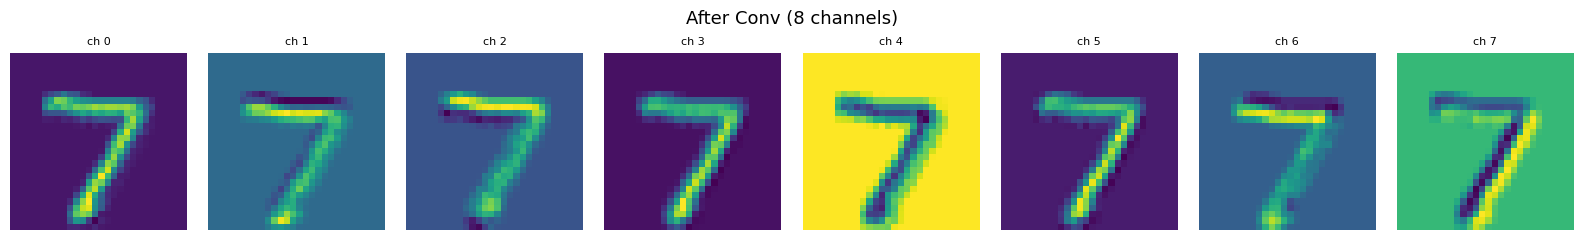

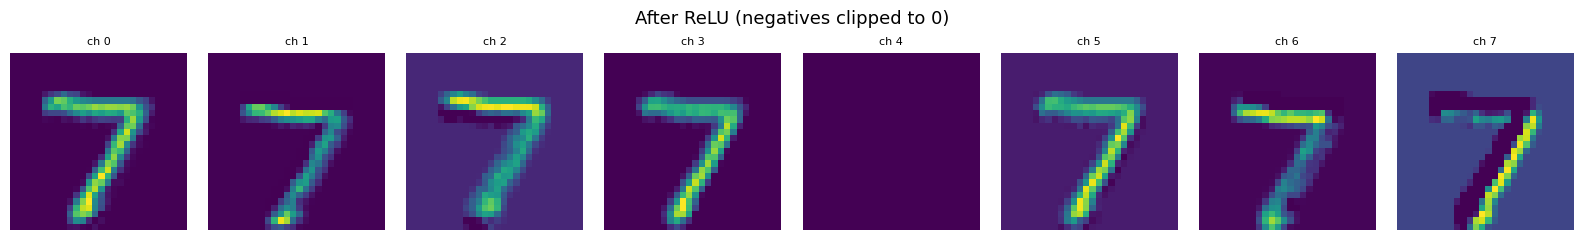

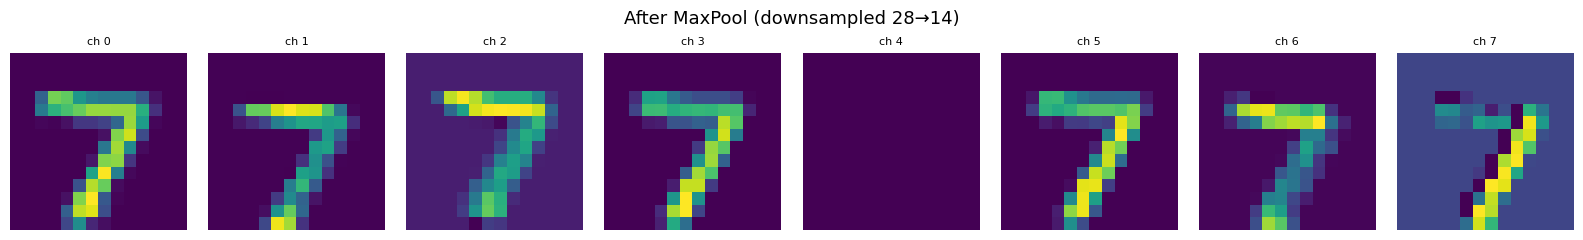

In [ ]:
import matplotlib.pyplot as plt

# pick one test image
img = torch.from_numpy(X_test[0]).unsqueeze(0).unsqueeze(0).to(device)  # (1,1,28,28)
label = y_test[0]

model.eval()
with torch.no_grad():
    fmap_conv = model.conv1(img)        # after Conv
    fmap_relu = F.relu(fmap_conv)       # after ReLU
    fmap_pool = model.pool(fmap_relu)   # after MaxPool

print(f"Input label: {label}")
print("conv1:", tuple(fmap_conv.shape), "| relu:", tuple(fmap_relu.shape), "| pool:", tuple(fmap_pool.shape))

def show_maps(tensor, title):
    maps = tensor.squeeze(0).cpu().numpy()   # (C, H, W)
    n = maps.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(2*n, 2.4))
    fig.suptitle(title, fontsize=13)
    for i, ax in enumerate(np.atleast_1d(axes)):
        ax.imshow(maps[i], cmap='viridis')
        ax.axis('off')
        ax.set_title(f'ch {i}', fontsize=8)
    plt.tight_layout()
    plt.show()

# original
plt.figure(figsize=(2.4, 2.4))
plt.imshow(X_test[0], cmap='gray'); plt.title(f"Input (label {label})"); plt.axis('off'); plt.show()

# the three stages of the pipeline
show_maps(fmap_conv, "After Conv (8 channels)")
show_maps(fmap_relu, "After ReLU (negatives clipped to 0)")
show_maps(fmap_pool, "After MaxPool (downsampled 28→14)")